In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV,
    learning_curve
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("XGBoost Available:", HAS_XGB)

XGBoost Available: True


In [ ]:
DATA_PATH = "ev_data.xls"

raw_df = pd.read_excel(DATA_PATH)

print("Dataset Shape:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())

print("\nDataset Information:")
raw_df.info()

raw_df.head()

Dataset Shape: (478, 22)

Columns:
['brand', 'model', 'top_speed_kmh', 'battery_capacity_kWh', 'battery_type', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km', 'range_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'fast_charge_port', 'towing_capacity_kg', 'cargo_volume_l', 'seats', 'drivetrain', 'segment', 'length_mm', 'width_mm', 'height_mm', 'car_body_type', 'source_url']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand                      478 non-null    object 
 1   model                      477 non-null    object 
 2   top_speed_kmh              478 non-null    int64  
 3   battery_capacity_kWh       478 non-null    float64
 4   battery_type               478 non-null    object 
 5   number_of_cells            276 non-null    float64
 6   torque_nm                

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5


In [ ]:
print("Missing Values:\n")
display(raw_df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate Rows:", raw_df.duplicated().sum())

print("\nUnique Values Per Column:")
display(raw_df.nunique().sort_values())

Missing Values:



,0
number_of_cells,202
towing_capacity_kg,26
torque_nm,7
fast_charging_power_kw_dc,1
fast_charge_port,1
model,1
cargo_volume_l,1
battery_capacity_kWh,0
top_speed_kmh,0
brand,0



Duplicate Rows: 0

Unique Values Per Column:


,0
battery_type,1
fast_charge_port,2
drivetrain,3
seats,7
car_body_type,8
segment,15
towing_capacity_kg,26
top_speed_kmh,38
number_of_cells,38
brand,59


,Column,Missing Values,Percentage
5,number_of_cells,202,42.26
12,towing_capacity_kg,26,5.44
6,torque_nm,7,1.46
1,model,1,0.21
10,fast_charging_power_kw_dc,1,0.21
11,fast_charge_port,1,0.21
13,cargo_volume_l,1,0.21


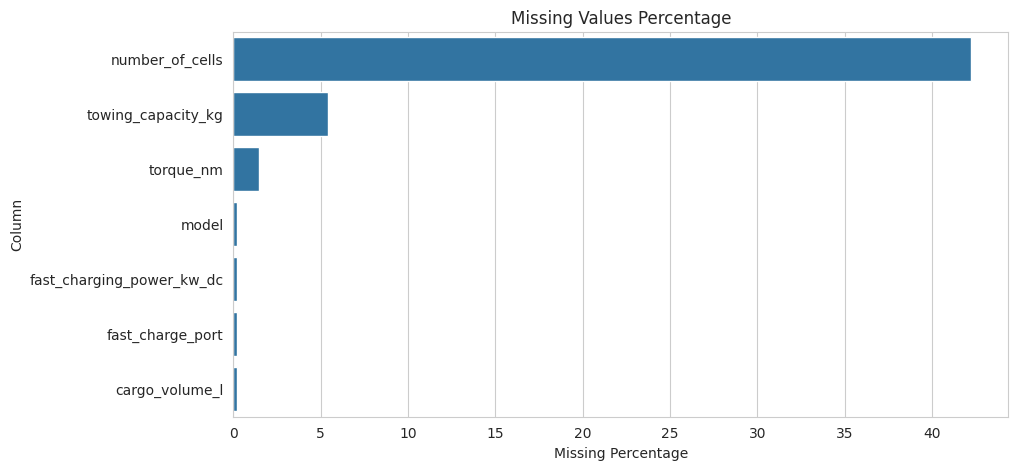

In [ ]:
missing = raw_df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Percentage": (missing.values / len(raw_df) * 100).round(2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df = missing_df.sort_values("Percentage", ascending=False)

display(missing_df)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=missing_df,
    x="Percentage",
    y="Column"
)

plt.title("Missing Values Percentage")
plt.xlabel("Missing Percentage")
plt.show()

In [ ]:
df = raw_df.copy()

# --------------------------------------------------
# Remove ID / URL columns
# --------------------------------------------------

drop_columns = [
    "model",
    "source_url",
    "battery_type",
    "fast_charge_port",
    "number_of_cells"
]

drop_columns = [col for col in drop_columns if col in df.columns]

df.drop(columns=drop_columns, inplace=True)

# --------------------------------------------------
# Convert cargo volume to numeric
# Some rows contain non-numeric text
# --------------------------------------------------

if "cargo_volume_l" in df.columns:

    df["cargo_volume_l"] = pd.to_numeric(
        df["cargo_volume_l"],
        errors="coerce"
    )

# --------------------------------------------------
# Missing flag for towing capacity
# --------------------------------------------------

if "towing_capacity_kg" in df.columns:

    df["towing_capacity_missing"] = (
        df["towing_capacity_kg"]
        .isnull()
        .astype(int)
    )

# --------------------------------------------------
# Remove duplicate rows
# --------------------------------------------------

df.drop_duplicates(inplace=True)

print("Final Shape After Cleaning:", df.shape)

print("\nRemaining Missing Values:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Final Shape After Cleaning: (471, 18)

Remaining Missing Values:


,0
torque_nm,7
fast_charging_power_kw_dc,1
towing_capacity_kg,26
cargo_volume_l,4


In [ ]:
df = raw_df.copy()

# --------------------------------------------------
# Remove ID / URL columns
# --------------------------------------------------

drop_columns = [
    "model",
    "source_url",
    "battery_type",
    "fast_charge_port",
    "number_of_cells"
]

drop_columns = [col for col in drop_columns if col in df.columns]

df.drop(columns=drop_columns, inplace=True)

# --------------------------------------------------
# Convert cargo volume to numeric
# Some rows contain non-numeric text
# --------------------------------------------------

if "cargo_volume_l" in df.columns:

    df["cargo_volume_l"] = pd.to_numeric(
        df["cargo_volume_l"],
        errors="coerce"
    )

# --------------------------------------------------
# Missing flag for towing capacity
# --------------------------------------------------

if "towing_capacity_kg" in df.columns:

    df["towing_capacity_missing"] = (
        df["towing_capacity_kg"]
        .isnull()
        .astype(int)
    )

# --------------------------------------------------
# Remove duplicate rows
# --------------------------------------------------

df.drop_duplicates(inplace=True)

print("Final Shape After Cleaning:", df.shape)

print("\nRemaining Missing Values:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Final Shape After Cleaning: (471, 18)

Remaining Missing Values:


,0
torque_nm,7
fast_charging_power_kw_dc,1
towing_capacity_kg,26
cargo_volume_l,4


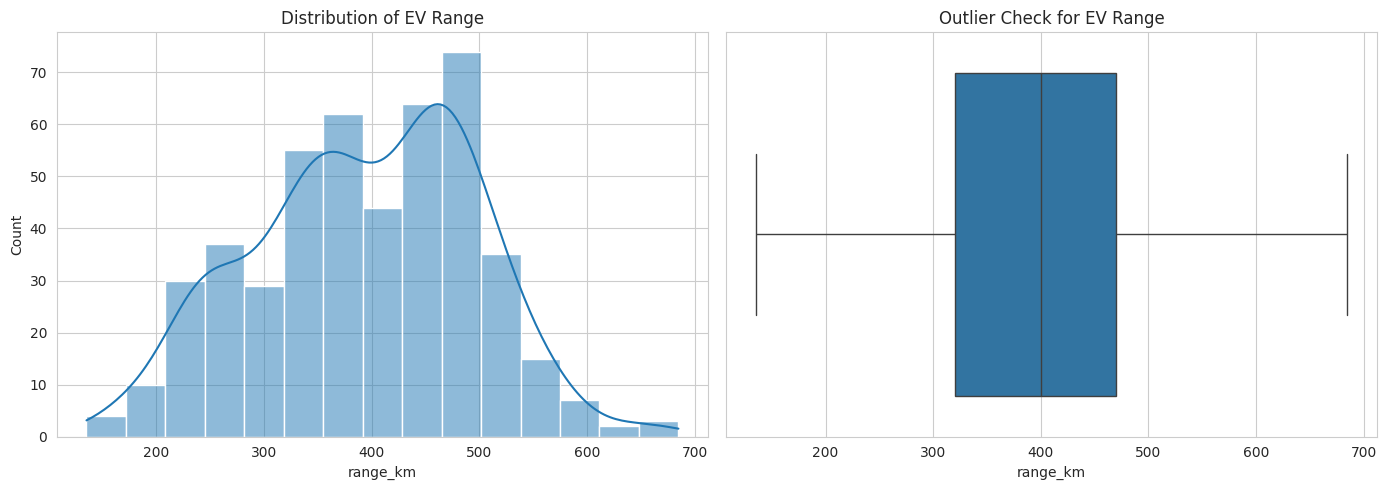

count    471.000000
mean     393.694268
std      102.844356
min      135.000000
25%      320.000000
50%      400.000000
75%      470.000000
max      685.000000
Name: range_km, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
sns.histplot(
    df["range_km"],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of EV Range")

# Boxplot
sns.boxplot(
    x=df["range_km"],
    ax=axes[1]
)

axes[1].set_title("Outlier Check for EV Range")

plt.tight_layout()
plt.show()

print(df["range_km"].describe())

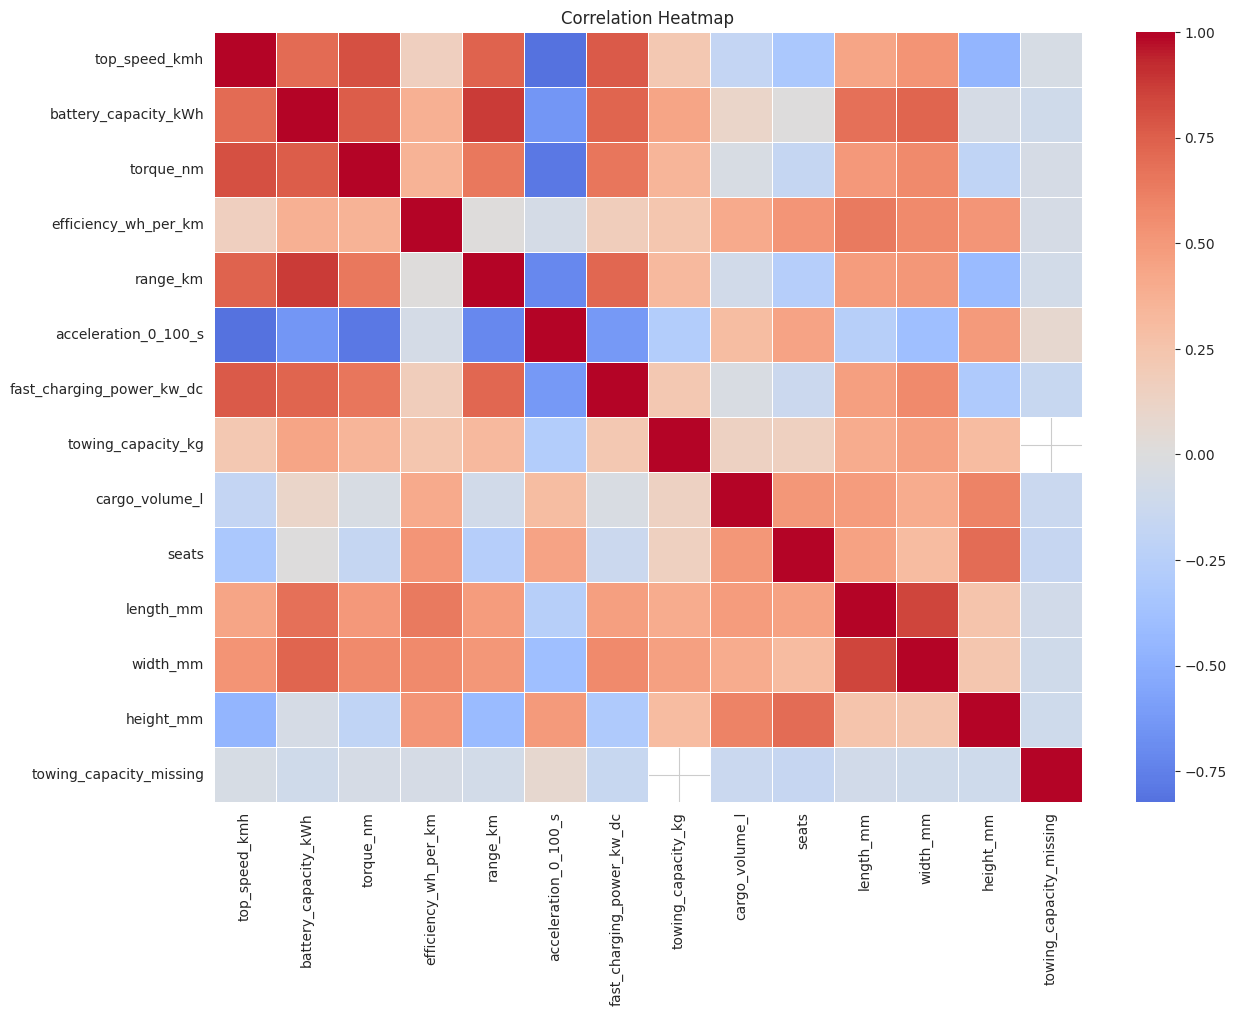

Correlation With Target:



,range_km
range_km,1.000000
battery_capacity_kWh,0.877674
top_speed_kmh,0.730666
fast_charging_power_kw_dc,0.718324
torque_nm,0.650424
width_mm,0.510082
length_mm,0.486489
towing_capacity_kg,0.322517
efficiency_wh_per_km,0.010580
towing_capacity_missing,-0.080634


In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

print("Correlation With Target:\n")

target_corr = (
    correlation["range_km"]
    .sort_values(ascending=False)
)

display(target_corr)

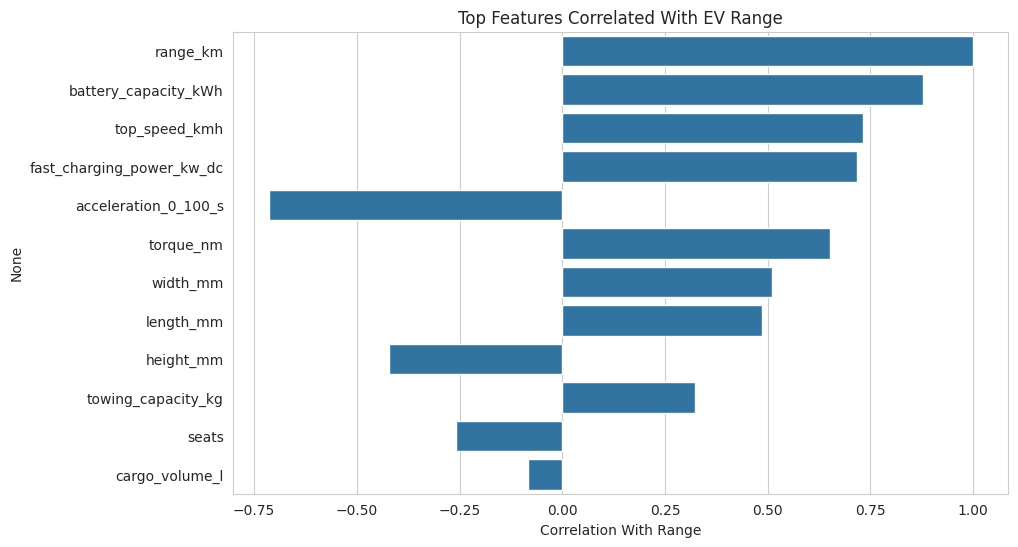

In [ ]:
top_corr_features = (
    target_corr.abs()
    .sort_values(ascending=False)
    .head(12)
    .index
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=target_corr[top_corr_features].values,
    y=top_corr_features
)

plt.title("Top Features Correlated With EV Range")
plt.xlabel("Correlation With Range")
plt.show()

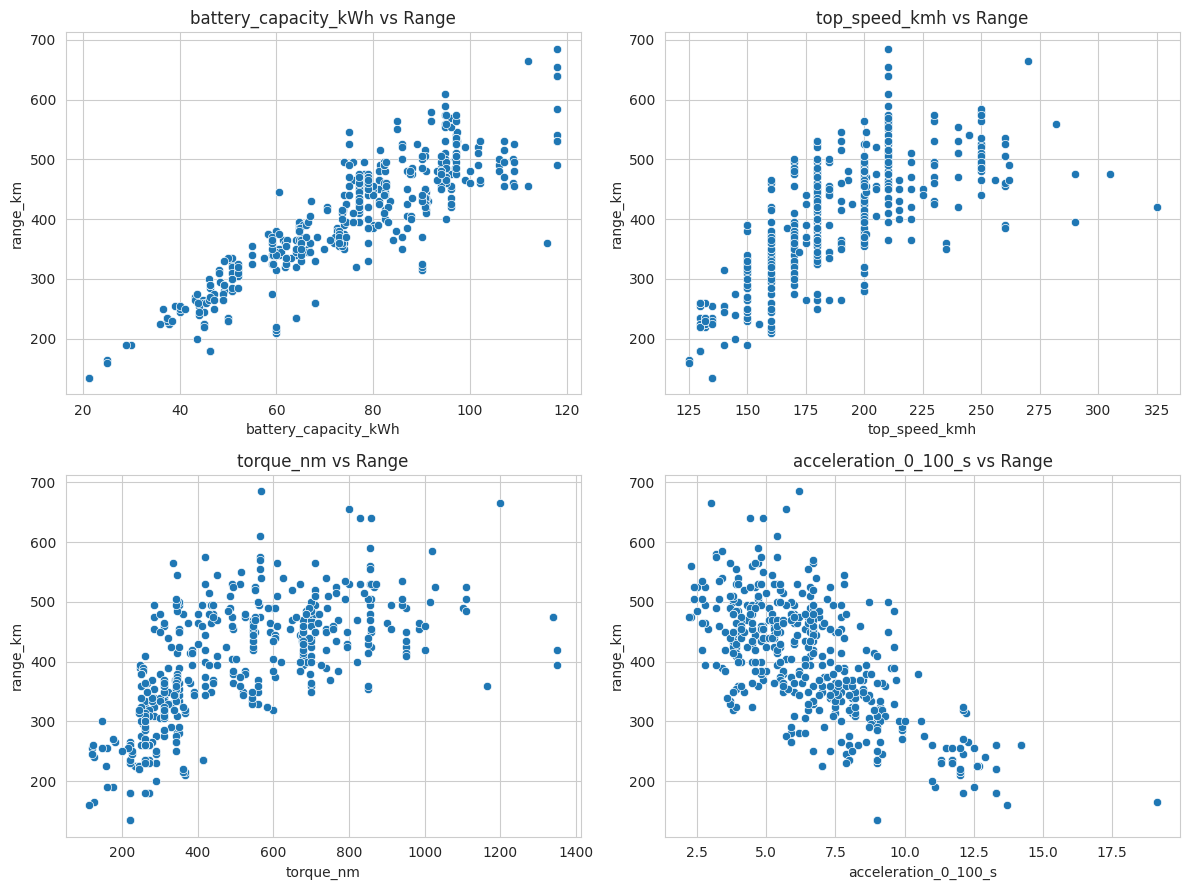

In [ ]:
important_features = [
    "battery_capacity_kWh",
    "top_speed_kmh",
    "torque_nm",
    "acceleration_0_100_s"
]

important_features = [
    col for col in important_features
    if col in df.columns
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

axes = axes.flatten()

for i, feature in enumerate(important_features):

    sns.scatterplot(
        data=df,
        x=feature,
        y="range_km",
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature} vs Range"
    )

plt.tight_layout()
plt.show()

In [ ]:
df_model = df.copy()

# --------------------------------------------------
# Remove efficiency because it can indirectly
# reconstruct range using battery capacity
# --------------------------------------------------

if "efficiency_wh_per_km" in df_model.columns:

    df_model.drop(
        columns=["efficiency_wh_per_km"],
        inplace=True
    )

# --------------------------------------------------
# Feature Engineering
# --------------------------------------------------

# Vehicle footprint
df_model["footprint_m2"] = (
    df_model["length_mm"]
    * df_model["width_mm"]
) / 1e6

# Approx vehicle volume
df_model["vehicle_volume_m3"] = (
    df_model["length_mm"]
    * df_model["width_mm"]
    * df_model["height_mm"]
) / 1e9

# Battery capacity per seat
df_model["battery_per_seat"] = (
    df_model["battery_capacity_kWh"]
    / df_model["seats"]
)

# Power to battery ratio
df_model["charge_power_ratio"] = (
    df_model["fast_charging_power_kw_dc"]
    / df_model["battery_capacity_kWh"]
)

# Torque efficiency
df_model["torque_per_battery"] = (
    df_model["torque_nm"]
    / df_model["battery_capacity_kWh"]
)

# Performance ratio
df_model["speed_acceleration_ratio"] = (
    df_model["top_speed_kmh"]
    / df_model["acceleration_0_100_s"]
)

# --------------------------------------------------
# Handle Infinity
# --------------------------------------------------

df_model.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

print("Shape After Feature Engineering:")
print(df_model.shape)

df_model.head()

Shape After Feature Engineering:
(471, 23)


,brand,top_speed_kmh,battery_capacity_kWh,torque_nm,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,cargo_volume_l,seats,...,width_mm,height_mm,car_body_type,towing_capacity_missing,footprint_m2,vehicle_volume_m3,battery_per_seat,charge_power_ratio,torque_per_battery,speed_acceleration_ratio
0,Abarth,155,37.8,235.0,225,7.0,67.0,0.0,185.0,4,...,1683,1518,Hatchback,0,6.181659,9.383758,9.45,1.772487,6.216931,22.142857
1,Abarth,155,37.8,235.0,225,7.0,67.0,0.0,185.0,4,...,1683,1518,Hatchback,0,6.181659,9.383758,9.45,1.772487,6.216931,22.142857
2,Abarth,200,50.8,345.0,280,5.9,79.0,0.0,360.0,5,...,1779,1557,SUV,0,7.448673,11.597584,10.16,1.555118,6.791339,33.898305
3,Abarth,200,50.8,345.0,280,6.2,79.0,0.0,360.0,5,...,1779,1557,SUV,0,7.448673,11.597584,10.16,1.555118,6.791339,32.258065
4,Aiways,150,60.0,310.0,315,7.5,78.0,NaN,496.0,5,...,1865,1700,SUV,1,8.728200,14.837940,12.00,1.300000,5.166667,20.000000


In [ ]:
numeric_columns = df_model.select_dtypes(
    include=np.number
).columns.tolist()

numeric_columns.remove("range_km")

for col in numeric_columns:

    Q1 = df_model[col].quantile(0.01)
    Q99 = df_model[col].quantile(0.99)

    df_model[col] = df_model[col].clip(
        lower=Q1,
        upper=Q99
    )

print("Extreme values capped using 1st and 99th percentile.")

Extreme values capped using 1st and 99th percentile.


In [ ]:
y = df_model["range_km"]

X = df_model.drop(
    columns=["range_km"]
)

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numeric Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))

print("\nNumeric:")
print(numeric_features)

print("\nCategorical:")
print(categorical_features)

Numeric Features: 18
Categorical Features: 4

Numeric:
['top_speed_kmh', 'battery_capacity_kWh', 'torque_nm', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'cargo_volume_l', 'seats', 'length_mm', 'width_mm', 'height_mm', 'towing_capacity_missing', 'footprint_m2', 'vehicle_volume_m3', 'battery_per_seat', 'charge_power_ratio', 'torque_per_battery', 'speed_acceleration_ratio']

Categorical:
['brand', 'drivetrain', 'segment', 'car_body_type']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=RANDOM_STATE
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


# Numeric preprocessing

numeric_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "scaler",
        StandardScaler()
    )

])


# Categorical preprocessing

categorical_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),

    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )

])


# Combine preprocessing

preprocessor = ColumnTransformer([

    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),

    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )

])

Training Samples: 376
Testing Samples: 95


In [ ]:
models = {

    "Ridge Regression":

    Ridge(alpha=10),


    "Random Forest":

    RandomForestRegressor(

        n_estimators=300,

        max_depth=10,

        min_samples_split=5,

        random_state=RANDOM_STATE
    ),


    "Gradient Boosting":

    GradientBoostingRegressor(

        n_estimators=300,

        learning_rate=0.05,

        max_depth=3,

        random_state=RANDOM_STATE
    )

}


if HAS_XGB:

    models["XGBoost"] = XGBRegressor(

        n_estimators=300,

        learning_rate=0.05,

        max_depth=4,

        subsample=0.8,

        colsample_bytree=0.8,

        objective="reg:squarederror",

        random_state=RANDOM_STATE
    )


print("Models Used:")

for model in models:

    print("-", model)

Models Used:
- Ridge Regression
- Random Forest
- Gradient Boosting
- XGBoost


In [ ]:
kf = KFold(

    n_splits=5,

    shuffle=True,

    random_state=RANDOM_STATE
)


results = []


for name, model in models.items():

    pipeline = Pipeline([

        ("preprocessor", preprocessor),

        ("model", model)

    ])


    scores = cross_validate(

        pipeline,

        X_train,

        y_train,

        cv=kf,

        scoring={

            "R2": "r2",

            "MAE": "neg_mean_absolute_error",

            "RMSE": "neg_root_mean_squared_error"

        },

        return_train_score=True

    )


    results.append({

        "Model": name,

        "Train R2":
        scores["train_R2"].mean(),

        "CV R2":
        scores["test_R2"].mean(),

        "Overfit Gap":
        scores["train_R2"].mean()
        -
        scores["test_R2"].mean(),

        "CV MAE":
        -scores["test_MAE"].mean(),

        "CV RMSE":
        -scores["test_RMSE"].mean()

    })


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(

    by="CV RMSE"

).reset_index(drop=True)


display(results_df)

,Model,Train R2,CV R2,Overfit Gap,CV MAE,CV RMSE
0,Gradient Boosting,0.995293,0.950299,0.044994,15.439801,23.073834
1,XGBoost,0.998656,0.949388,0.049268,15.160342,23.304939
2,Ridge Regression,0.963093,0.947870,0.015223,18.294442,23.572276
3,Random Forest,0.987445,0.934412,0.053033,18.635142,26.472889


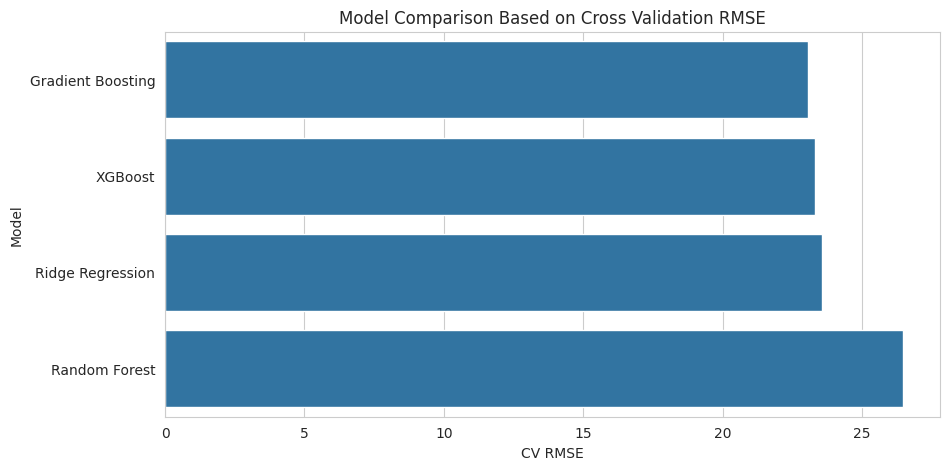

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(

    data=results_df,

    x="CV RMSE",

    y="Model"

)

plt.title("Model Comparison Based on Cross Validation RMSE")

plt.show()

In [ ]:
ridge_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", Ridge())

])


ridge_grid = {

    "model__alpha":

    [0.1, 1, 5, 10, 20, 50]

}


ridge_search = GridSearchCV(

    ridge_pipeline,

    ridge_grid,

    cv=kf,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1

)


ridge_search.fit(X_train, y_train)


print("Best Ridge Parameters:")

print(ridge_search.best_params_)

print("Best CV RMSE:")

print(-ridge_search.best_score_)

Best Ridge Parameters:
{'model__alpha': 1}
Best CV RMSE:
20.243887655416394


In [ ]:
ridge_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", Ridge())

])


ridge_grid = {

    "model__alpha":

    [0.1, 1, 5, 10, 20, 50]

}


ridge_search = GridSearchCV(

    ridge_pipeline,

    ridge_grid,

    cv=kf,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1

)


ridge_search.fit(X_train, y_train)


print("Best Ridge Parameters:")

print(ridge_search.best_params_)

print("Best CV RMSE:")

print(-ridge_search.best_score_)

Best Ridge Parameters:
{'model__alpha': 1}
Best CV RMSE:
20.243887655416394


In [ ]:
if HAS_XGB:

    xgb_pipeline = Pipeline([

        ("preprocessor", preprocessor),

        ("model",

         XGBRegressor(

             objective="reg:squarederror",

             random_state=RANDOM_STATE

         )

        )

    ])


    xgb_grid = {

        "model__n_estimators":

        [200, 300],


        "model__max_depth":

        [3, 4, 5],


        "model__learning_rate":

        [0.03, 0.05, 0.1]

    }


    xgb_search = GridSearchCV(

        xgb_pipeline,

        xgb_grid,

        cv=kf,

        scoring="neg_root_mean_squared_error",

        n_jobs=-1

    )


    xgb_search.fit(

        X_train,

        y_train

    )


    print("Best XGBoost Parameters:")

    print(xgb_search.best_params_)

    print("Best CV RMSE:")

    print(-xgb_search.best_score_)

Best XGBoost Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300}
Best CV RMSE:
22.838220596313477


In [ ]:
candidate_models = {

    "Ridge":

    ridge_search.best_estimator_

}


if HAS_XGB:

    candidate_models["XGBoost"] = xgb_search.best_estimator_


best_model_name = None

best_score = float("inf")


for name, model in candidate_models.items():

    scores = cross_validate(

        model,

        X_train,

        y_train,

        cv=kf,

        scoring="neg_root_mean_squared_error"

    )


    score = -scores["test_score"].mean()


    print(

        f"{name}: CV RMSE = {score:.2f}"

    )


    if score < best_score:

        best_score = score

        best_model_name = name

        FINAL_MODEL = model


print("\nFinal Selected Model:")

print(best_model_name)

Ridge: CV RMSE = 20.24
XGBoost: CV RMSE = 22.84

Final Selected Model:
Ridge


In [ ]:
FINAL_MODEL.fit(

    X_train,

    y_train

)


# Predictions

train_pred = FINAL_MODEL.predict(X_train)

test_pred = FINAL_MODEL.predict(X_test)


# Metrics

train_r2 = r2_score(

    y_train,

    train_pred

)


test_r2 = r2_score(

    y_test,

    test_pred

)


mae = mean_absolute_error(

    y_test,

    test_pred

)


rmse = np.sqrt(

    mean_squared_error(

        y_test,

        test_pred

    )

)


print("=" * 50)

print("FINAL MODEL:", best_model_name)

print("=" * 50)

print(f"Train R² : {train_r2:.4f}")

print(f"Test R²  : {test_r2:.4f}")

print(f"MAE      : {mae:.2f} km")

print(f"RMSE     : {rmse:.2f} km")

print(f"Overfit Gap : {train_r2 - test_r2:.4f}")

FINAL MODEL: Ridge
Train R² : 0.9792
Test R²  : 0.9745
MAE      : 12.11 km
RMSE     : 15.33 km
Overfit Gap : 0.0047


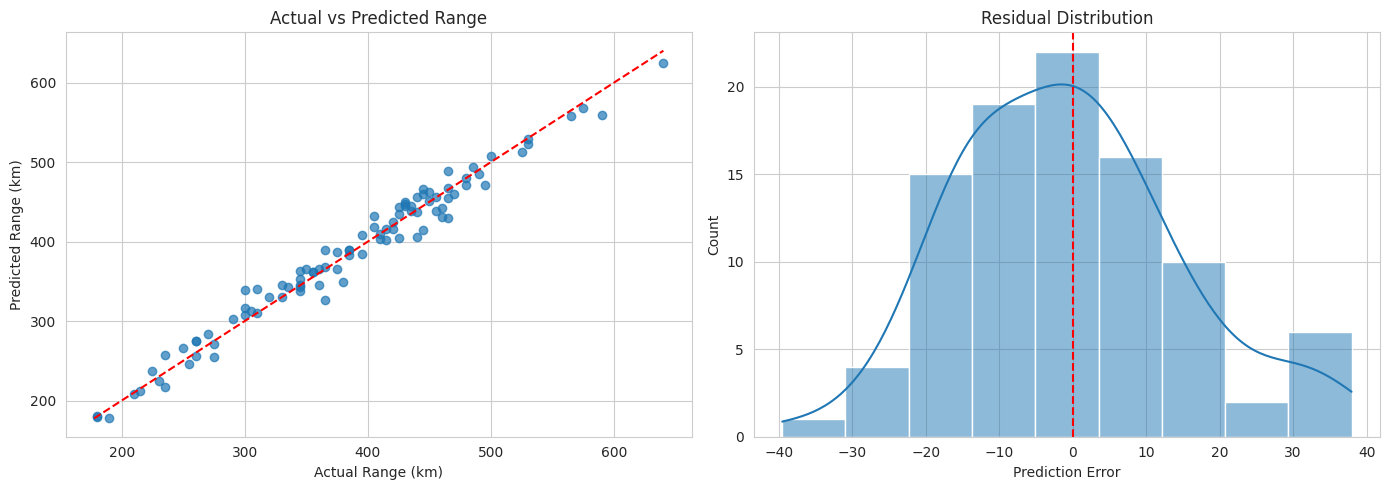

In [ ]:
fig, axes = plt.subplots(

    1,

    2,

    figsize=(14, 5)

)


# Actual vs predicted

axes[0].scatter(

    y_test,

    test_pred,

    alpha=0.7

)


min_val = min(

    y_test.min(),

    test_pred.min()

)


max_val = max(

    y_test.max(),

    test_pred.max()

)


axes[0].plot(

    [min_val, max_val],

    [min_val, max_val],

    "r--"

)


axes[0].set_xlabel("Actual Range (km)")

axes[0].set_ylabel("Predicted Range (km)")

axes[0].set_title("Actual vs Predicted Range")


# Residuals

residuals = y_test - test_pred


sns.histplot(

    residuals,

    kde=True,

    ax=axes[1]

)


axes[1].axvline(

    0,

    color="red",

    linestyle="--"

)


axes[1].set_title("Residual Distribution")

axes[1].set_xlabel("Prediction Error")

plt.tight_layout()

plt.show()

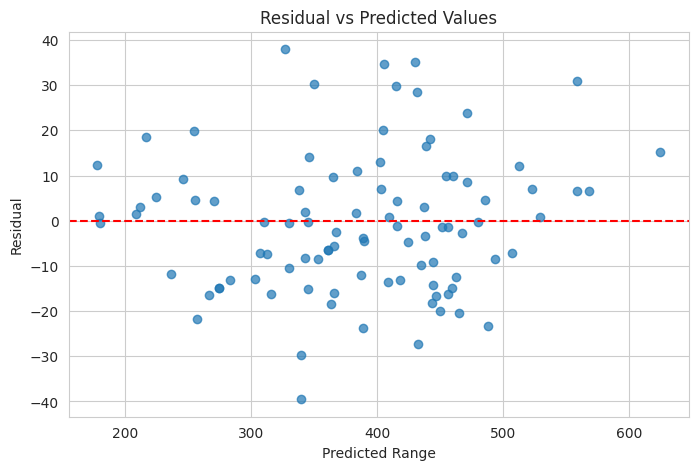

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(

    test_pred,

    residuals,

    alpha=0.7

)


plt.axhline(

    0,

    color="red",

    linestyle="--"

)


plt.xlabel("Predicted Range")

plt.ylabel("Residual")

plt.title("Residual vs Predicted Values")

plt.show()

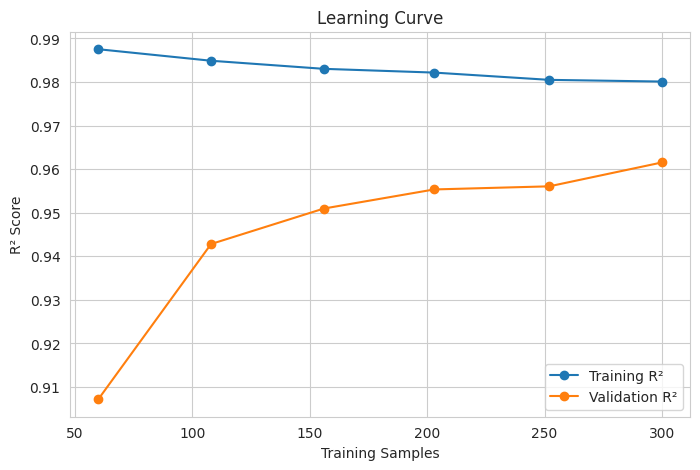

Samples: 60 | Train R²: 0.988 | Validation R²: 0.907 | Gap: 0.080
Samples: 108 | Train R²: 0.985 | Validation R²: 0.943 | Gap: 0.042
Samples: 156 | Train R²: 0.983 | Validation R²: 0.951 | Gap: 0.032
Samples: 203 | Train R²: 0.982 | Validation R²: 0.955 | Gap: 0.027
Samples: 252 | Train R²: 0.981 | Validation R²: 0.956 | Gap: 0.024
Samples: 300 | Train R²: 0.980 | Validation R²: 0.962 | Gap: 0.019


In [ ]:
train_sizes, train_scores, validation_scores = learning_curve(

    FINAL_MODEL,

    X_train,

    y_train,

    cv=kf,

    scoring="r2",

    train_sizes=np.linspace(

        0.2,

        1.0,

        6

    ),

    n_jobs=-1

)


train_mean = train_scores.mean(axis=1)

validation_mean = validation_scores.mean(axis=1)


plt.figure(figsize=(8, 5))


plt.plot(

    train_sizes,

    train_mean,

    marker="o",

    label="Training R²"

)


plt.plot(

    train_sizes,

    validation_mean,

    marker="o",

    label="Validation R²"

)


plt.xlabel("Training Samples")

plt.ylabel("R² Score")

plt.title("Learning Curve")

plt.legend()

plt.show()


for size, train_score, val_score in zip(

    train_sizes,

    train_mean,

    validation_mean

):

    print(

        f"Samples: {int(size)} | "

        f"Train R²: {train_score:.3f} | "

        f"Validation R²: {val_score:.3f} | "

        f"Gap: {train_score - val_score:.3f}"

    )

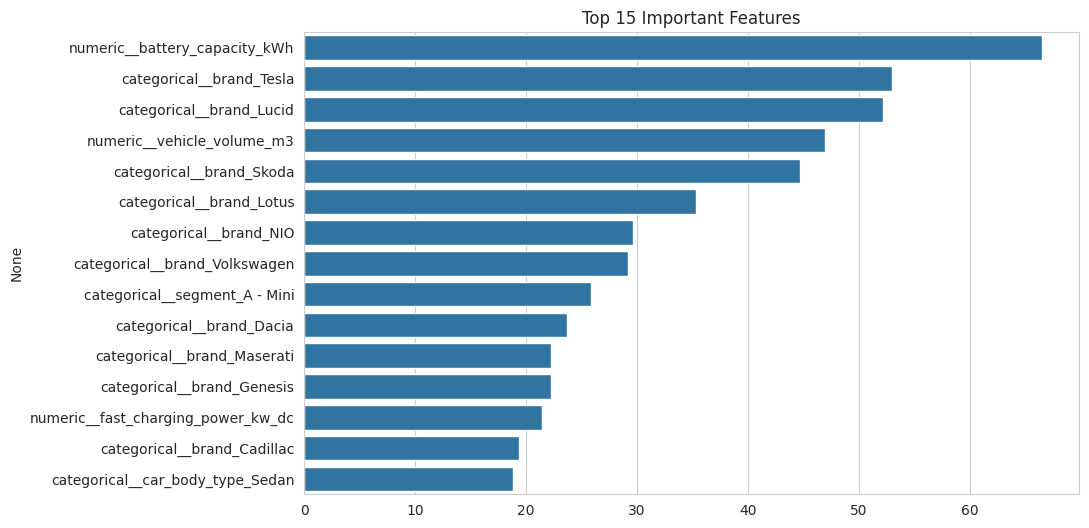

,0
numeric__battery_capacity_kWh,66.550699
categorical__brand_Tesla,53.025316
categorical__brand_Lucid,52.152298
numeric__vehicle_volume_m3,46.955668
categorical__brand_Skoda,44.673092
categorical__brand_Lotus,35.349612
categorical__brand_NIO,29.644070
categorical__brand_Volkswagen,29.203744
categorical__segment_A - Mini,25.860772
categorical__brand_Dacia,23.728797


In [ ]:
feature_names = (

    FINAL_MODEL

    .named_steps["preprocessor"]

    .get_feature_names_out()

)


model = FINAL_MODEL.named_steps["model"]


if hasattr(model, "feature_importances_"):

    importance = pd.Series(

        model.feature_importances_,

        index=feature_names

    )


elif hasattr(model, "coef_"):

    importance = pd.Series(

        np.abs(model.coef_),

        index=feature_names

    )


importance = importance.sort_values(

    ascending=False

).head(15)


plt.figure(figsize=(10, 6))


sns.barplot(

    x=importance.values,

    y=importance.index

)


plt.title("Top 15 Important Features")

plt.show()


display(importance)

In [ ]:
def predict_ev_range(input_data):

    try:

        data = pd.DataFrame([input_data])


        # ------------------------------------------
        # Prevent negative physical values
        # ------------------------------------------

        positive_columns = [

            "battery_capacity_kWh",

            "top_speed_kmh",

            "torque_nm",

            "acceleration_0_100_s",

            "fast_charging_power_kw_dc",

            "cargo_volume_l",

            "seats",

            "length_mm",

            "width_mm",

            "height_mm"

        ]


        for col in positive_columns:

            if col in data.columns:

                if data[col].iloc[0] < 0:

                    raise ValueError(

                        f"{col} cannot be negative"

                    )


        # ------------------------------------------
        # Prevent division by zero
        # ------------------------------------------

        if data["battery_capacity_kWh"].iloc[0] <= 0:

            raise ValueError(

                "Battery capacity must be greater than zero"

            )


        if data["seats"].iloc[0] <= 0:

            raise ValueError(

                "Seats must be greater than zero"

            )


        if data["acceleration_0_100_s"].iloc[0] <= 0:

            raise ValueError(

                "Acceleration time must be greater than zero"

            )


        # ------------------------------------------
        # Create engineered features
        # ------------------------------------------

        data["footprint_m2"] = (

            data["length_mm"]

            * data["width_mm"]

        ) / 1e6


        data["vehicle_volume_m3"] = (

            data["length_mm"]

            * data["width_mm"]

            * data["height_mm"]

        ) / 1e9


        data["battery_per_seat"] = (

            data["battery_capacity_kWh"]

            / data["seats"]

        )


        data["charge_power_ratio"] = (

            data["fast_charging_power_kw_dc"]

            / data["battery_capacity_kWh"]

        )


        data["torque_per_battery"] = (

            data["torque_nm"]

            / data["battery_capacity_kWh"]

        )


        data["speed_acceleration_ratio"] = (

            data["top_speed_kmh"]

            / data["acceleration_0_100_s"]

        )


        # ------------------------------------------
        # Replace invalid values
        # ------------------------------------------

        data.replace(

            [np.inf, -np.inf],

            np.nan,

            inplace=True

        )


        # Keep same feature order

        data = data[X.columns]


        prediction = FINAL_MODEL.predict(data)[0]


        # Range should never be negative

        prediction = max(

            0,

            prediction

        )


        print(

            f"Predicted EV Range: {prediction:.2f} km"

        )


        return prediction


    except Exception as e:

        print(

            "Prediction Error:",

            e

        )

In [ ]:
def predict_ev_range(input_data):

    try:

        data = pd.DataFrame([input_data])


        # ------------------------------------------
        # Prevent negative physical values
        # ------------------------------------------

        positive_columns = [

            "battery_capacity_kWh",

            "top_speed_kmh",

            "torque_nm",

            "acceleration_0_100_s",

            "fast_charging_power_kw_dc",

            "cargo_volume_l",

            "seats",

            "length_mm",

            "width_mm",

            "height_mm"

        ]


        for col in positive_columns:

            if col in data.columns:

                if data[col].iloc[0] < 0:

                    raise ValueError(

                        f"{col} cannot be negative"

                    )


        # ------------------------------------------
        # Prevent division by zero
        # ------------------------------------------

        if data["battery_capacity_kWh"].iloc[0] <= 0:

            raise ValueError(

                "Battery capacity must be greater than zero"

            )


        if data["seats"].iloc[0] <= 0:

            raise ValueError(

                "Seats must be greater than zero"

            )


        if data["acceleration_0_100_s"].iloc[0] <= 0:

            raise ValueError(

                "Acceleration time must be greater than zero"

            )


        # ------------------------------------------
        # Create engineered features
        # ------------------------------------------

        data["footprint_m2"] = (

            data["length_mm"]

            * data["width_mm"]

        ) / 1e6


        data["vehicle_volume_m3"] = (

            data["length_mm"]

            * data["width_mm"]

            * data["height_mm"]

        ) / 1e9


        data["battery_per_seat"] = (

            data["battery_capacity_kWh"]

            / data["seats"]

        )


        data["charge_power_ratio"] = (

            data["fast_charging_power_kw_dc"]

            / data["battery_capacity_kWh"]

        )


        data["torque_per_battery"] = (

            data["torque_nm"]

            / data["battery_capacity_kWh"]

        )


        data["speed_acceleration_ratio"] = (

            data["top_speed_kmh"]

            / data["acceleration_0_100_s"]

        )


        # ------------------------------------------
        # Replace invalid values
        # ------------------------------------------

        data.replace(

            [np.inf, -np.inf],

            np.nan,

            inplace=True

        )


        # Keep same feature order

        data = data[X.columns]


        prediction = FINAL_MODEL.predict(data)[0]


        # Range should never be negative

        prediction = max(

            0,

            prediction

        )


        print(

            f"Predicted EV Range: {prediction:.2f} km"

        )


        return prediction


    except Exception as e:

        print(

            "Prediction Error:",

            e

        )